In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path("..") / "data"          
AÑOS = [2020, 2021, 2022, 2023, 2024, 2025, 2026]
FIGURAS = Path("..") / "figuras"
FIGURAS.mkdir(exist_ok=True)

In [17]:
def leer_año(año):
    hojas = pd.read_excel(DATA / f"BD {año}.xlsx", sheet_name=None)
    tablas = []
    for estacion, df in hojas.items():
        # 1. Homologar nombres
        df.columns = [str(c).split(" (")[0] for c in df.columns]
        df = df.rename(columns={"date": "Fecha y hora"})

        # 2. Fechas válidas
        df["Fecha y hora"] = pd.to_datetime(df["Fecha y hora"], errors="coerce")
        df = df.dropna(subset=["Fecha y hora"])

        # 3. Todas las variables como números 
        variables = [c for c in df.columns if c != "Fecha y hora"]
        df[variables] = df[variables].apply(pd.to_numeric, errors="coerce")

        df["Estacion"] = estacion
        tablas.append(df)
    return pd.concat(tablas, ignore_index=True)

In [18]:
datos = pd.concat([leer_año(a) for a in AÑOS], ignore_index=True)

print(datos.shape)
print(datos.columns.tolist())
print(datos.groupby(datos["Fecha y hora"].dt.year).size())

(764485, 17)
['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'Estacion']
Fecha y hora
2020    114102
2021    122629
2022    123383
2023    131370
2024    131741
2025     64959
2026     76301
dtype: int64


In [19]:
# Variables que físicamente no pueden ser negativas (TOUT sí puede)
NO_NEGATIVAS = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5",
                "PRS", "RAINF", "RH", "SO2", "SR", "WSR", "WDR"]

negativos = (datos[NO_NEGATIVAS] < 0).sum()
datos[NO_NEGATIVAS] = datos[NO_NEGATIVAS].mask(datos[NO_NEGATIVAS] < 0)

filas_antes = len(datos)
datos = datos.drop_duplicates()
duplicados = filas_antes - len(datos)

repetidas = datos.duplicated(subset=["Estacion", "Fecha y hora"]).sum()

print("Valores negativos convertidos a faltante:")
print(negativos[negativos > 0])
print("Filas duplicadas eliminadas:", duplicados)
print("Misma estación y hora con valores distintos:", repetidas)

Valores negativos convertidos a faltante:
RH      2
SR    230
dtype: int64
Filas duplicadas eliminadas: 0
Misma estación y hora con valores distintos: 0


In [20]:
datos.to_csv(DATA / "base_observada.csv", index=False)
print(datos.shape)

(764485, 17)


In [22]:
revisiones = {
    "RH > 100 %":           datos["RH"] > 100,
    "WDR > 360°":           datos["WDR"] > 360,
    "PM2.5 > PM10":         datos["PM2.5"] > datos["PM10"],
    "NOX ≠ NO + NO2 (±5)":  (datos["NOX"] - (datos["NO"] + datos["NO2"])).abs() > 5,
    "TOUT fuera de -10 a 50 °C": (datos["TOUT"] < -10) | (datos["TOUT"] > 50),
}

for nombre, condicion in revisiones.items():
    n = condicion.sum()
    print(f"{nombre:<28} {n:>8,}  ({100 * n / len(datos):.2f} %)")

RH > 100 %                        283  (0.04 %)
WDR > 360°                          0  (0.00 %)
PM2.5 > PM10                       33  (0.00 %)
NOX ≠ NO + NO2 (±5)             1,035  (0.14 %)
TOUT fuera de -10 a 50 °C         430  (0.06 %)


In [23]:
#Magnitudes 
print("RH > 100:");  print(datos.loc[datos["RH"] > 100, "RH"].describe().round(1))
print("\nTOUT fuera de rango:")
print(datos.loc[(datos["TOUT"] < -10) | (datos["TOUT"] > 50), ["Estacion", "TOUT"]]
      .groupby("Estacion")["TOUT"].agg(["count", "min", "max"]))
print("\nNOX inconsistente por estación:")
print(datos.loc[(datos["NOX"] - (datos["NO"] + datos["NO2"])).abs() > 5, "Estacion"].value_counts())


RH > 100:
count    283.0
mean     104.3
std       37.1
min      101.0
25%      101.0
50%      101.0
75%      101.0
max      714.2
Name: RH, dtype: float64

TOUT fuera de rango:
          count      min     max
Estacion                        
NE            2 -9999.00  785.00
NE2           2    84.47  112.39
NTE         426   -67.49  -49.99

NOX inconsistente por estación:
Estacion
CE      610
NE2     298
NTE      46
NO2      37
NTE2     14
SO2       7
SE2       5
NO        4
SE3       3
SE        3
SO        3
NO3       2
NE3       2
SUR       1
Name: count, dtype: int64


In [24]:
#Correlaciones
correcciones = {}

# RH: recortar errores pequeños a 100; invalidar los grandes
correcciones["RH > 105 → faltante"] = (datos["RH"] > 105).sum()
datos.loc[datos["RH"] > 105, "RH"] = np.nan
correcciones["RH entre 100 y 105 → 100"] = (datos["RH"] > 100).sum()
datos["RH"] = datos["RH"].clip(upper=100)

# PM2.5 > PM10: imposible, no sabemos cuál falló -> ambos faltantes
malas_pm = datos["PM2.5"] > datos["PM10"]
correcciones["PM2.5 > PM10 → ambos faltantes"] = malas_pm.sum()
datos.loc[malas_pm, ["PM2.5", "PM10"]] = np.nan

# TOUT: fuera de rango físico -> faltante
malas_t = (datos["TOUT"] < -10) | (datos["TOUT"] > 50)
correcciones["TOUT fuera de [-10, 50] → faltante"] = malas_t.sum()
datos.loc[malas_t, "TOUT"] = np.nan

for k, v in correcciones.items():
    print(f"{k:<38} {v:>6,}")

RH > 105 → faltante                        12
RH entre 100 y 105 → 100                  271
PM2.5 > PM10 → ambos faltantes             33
TOUT fuera de [-10, 50] → faltante        430


In [25]:
fallas = datos[(datos["Estacion"] == "NTE") & datos["TOUT"].isna()]

In [50]:
#COVID 

import matplotlib.pyplot as plt

# 1. Misma ventana del confinamiento en todos los años: 1 de abril a 30 de mayo
f = datos["Fecha y hora"]
en_ventana = f.dt.month.isin([4, 5]) & ~((f.dt.month == 5) & (f.dt.day == 31))
ventana = datos[en_ventana].copy()

# 2. Promedio diario por estación (reduce la autocorrelación de los datos horarios)
ventana["dia"] = ventana["Fecha y hora"].dt.floor("D")
ventana["año"] = ventana["Fecha y hora"].dt.year
diario = (ventana.groupby(["Estacion", "dia", "año"])[["NO2", "O3", "CO", "PM10"]]
                 .mean().reset_index())
                 
estaciones_2020 = diario.loc[diario["año"] == 2020, "Estacion"].unique()
diario = diario[diario["Estacion"].isin(estaciones_2020)]
print("Estaciones comparadas:", len(estaciones_2020))

print(diario.groupby("año")[["NO2", "O3", "CO", "PM10"]].median().round(1))

Estaciones comparadas: 13
       NO2    O3   CO  PM10
año                        
2020   4.3  33.8  0.7  40.5
2021   9.4  31.8  0.8  55.5
2022  10.8  29.7  1.9  62.5
2023  14.3  25.9  0.9  51.9
2024  11.7  38.4  2.4  73.0
2025  10.9  36.3  0.7  45.2
2026  10.0  30.1  1.3  35.0


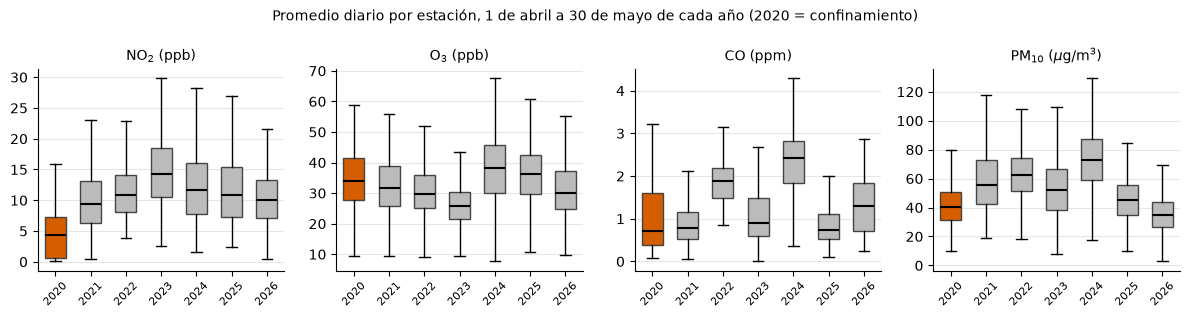

In [51]:
contaminantes = {"NO2": "NO$_2$ (ppb)", "O3": "O$_3$ (ppb)",
                 "CO": "CO (ppm)", "PM10": "PM$_{10}$ ($\\mu$g/m$^3$)"}
años = sorted(diario["año"].unique())

fig, ejes = plt.subplots(1, 4, figsize=(12, 3.2))
for eje, (var, etiqueta) in zip(ejes, contaminantes.items()):
    grupos = [diario.loc[diario["año"] == a, var].dropna() for a in años]
    cajas = eje.boxplot(grupos, tick_labels=años, showfliers=False, patch_artist=True,
                        widths=0.6, medianprops=dict(color="black", linewidth=1.5))
    for caja, a in zip(cajas["boxes"], años):
        caja.set_facecolor("#D55E00" if a == 2020 else "#BBBBBB")   # 2020 resaltado
        caja.set_edgecolor("#444444")
    eje.set_title(etiqueta, fontsize=10)
    eje.tick_params(axis="x", labelrotation=45, labelsize=8)
    eje.grid(axis="y", color="#E5E5E5", linewidth=0.8)
    eje.set_axisbelow(True)
    for lado in ["top", "right"]:
        eje.spines[lado].set_visible(False)

fig.suptitle("Promedio diario por estación, 1 de abril a 30 de mayo de cada año (2020 = confinamiento)",
             fontsize=10)
fig.tight_layout()
fig.savefig("../figuras/fig_covid.png", dpi=300)
plt.show()

Para el COVID: 

NO2: el efecto aquí si es claro, ya que la mediana del 2020 es de 4.3 contra 9 a 13 en los demás añis. Además, toda la caja de 2020 queda por debajo de las cajas de los otros años. Esto pues tiene sentido ya que es el contaminante más ligado al tráfico (hay una tabla más abajo que lo confirma)

O3: Aquí la mediana de 2020 es de 33.8 y es más alta que la de 2021 y los años sigueintes porque no quiero escribir todos los años pero es más baja que la de 2024 y 2025. Con esta info podemos decir que el efecto del confinamiento en el ozono es más pequeño que las diferencias normales de un año a otro. 

PM10: Este es más bajo que casi todos, porque su mediana en el 2020 es de 40.5, y es menor que en el 2021 a 2025 pero en el 2026 es más bajo que en el covid 35.2. Puede que tenga un efecto pero no se puede afirmar con esta sola figura. 

CO¡: aquí parece más un problema de datos que un problema que tenga que ver con el COVID, porque va alternando entre años altos y bajos. Esto puede ser por calibración y pues es un hallazgo de la calidad de los datos. 


*Para el modelo yo creo que hay que tomar en cuenta que debe de capturar las diferencias entre años, como una covariable de año o de tendencia ademñas de la hora y el mes. Y pues aquí una limitnte es que nosotros estamos comparando años después de la pandemia no antes entonces no sabemos qué tanto cambió la movilidad y así. 

In [ ]:
#Aquí ya no es COVID ya es de que todo
CONTAM = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "SO2"]

tabla = datos[CONTAM].describe(percentiles=[0.5, 0.9, 0.99]).T
tabla["% faltantes"] = 100 * datos[CONTAM].isna().mean()
tabla["asimetría"] = datos[CONTAM].skew()

columnas = ["count", "% faltantes", "mean", "50%", "std", "90%", "99%", "max", "asimetría"]
tabla[columnas].round(2) 

,count,% faltantes,mean,50%,std,90%,99%,max,asimetría
CO,662260.0,13.37,1.36,1.2,0.86,2.46,3.95,37.0,1.63
NO,635274.0,16.90,11.89,5.0,21.54,27.40,105.00,945.1,6.79
NO2,631026.0,17.46,14.35,11.2,11.27,29.10,52.80,188.6,2.00
NOX,636694.0,16.72,26.03,17.2,28.35,53.90,142.60,971.8,4.29
O3,656350.0,14.14,27.34,24.0,18.95,52.00,88.45,265.0,1.28
PM10,731593.0,4.30,57.34,48.0,39.83,100.00,201.00,1001.0,3.62
PM2.5,585857.0,23.37,20.25,17.0,14.95,38.00,70.00,763.0,4.02
SO2,653043.0,14.58,4.94,3.9,4.58,8.20,20.20,404.7,12.09


In [29]:
for var in CONTAM:
    top = datos[var].value_counts().sort_index(ascending=False).head(3)
    print(var, top.to_dict())

CO {37.0: 1, 32.0: 1, 22.38: 1}
NO {945.1: 1, 895.2: 1, 858.6: 1}
NO2 {188.6: 1, 173.9: 1, 168.5: 1}
NOX {971.8: 1, 897.0: 1, 874.9: 1}
O3 {265.0: 1, 222.0: 1, 209.0: 1}
PM10 {1001.0: 1, 1000.0: 2, 999.0: 2}
PM2.5 {763.0: 1, 729.0: 1, 690.0: 1}
SO2 {404.7: 1, 295.1: 1, 258.3: 1}


In [30]:
techo_pm10 = datos["PM10"] >= 999
print("PM10 en el límite del instrumento:", techo_pm10.sum())
datos.loc[techo_pm10, "PM10"] = np.nan

PM10 en el límite del instrumento: 5


In [31]:
def contexto(var, horas=3):
    fila = datos.loc[datos[var].idxmax()]
    mismo = ((datos["Estacion"] == fila["Estacion"]) &
             (datos["Fecha y hora"].between(fila["Fecha y hora"] - pd.Timedelta(hours=horas),
                                            fila["Fecha y hora"] + pd.Timedelta(hours=horas))))
    print(f"\n=== Máximo de {var}: {fila[var]} en {fila['Estacion']}, {fila['Fecha y hora']}")
    print(datos.loc[mismo, ["Fecha y hora", var, "NO", "NOX", "CO", "WSR"]]
          .sort_values("Fecha y hora").to_string(index=False))

for var in ["CO", "NO", "SO2", "PM2.5", "O3"]:
    contexto(var)


=== Máximo de CO: 37.0 en SE, 2024-05-22 20:00:00
       Fecha y hora    CO   NO  NOX    CO  WSR
2024-05-22 17:00:00  0.68  2.9 10.1  0.68 16.8
2024-05-22 18:00:00  0.68 11.6 27.1  0.68 17.2
2024-05-22 19:00:00  0.62 18.8 39.8  0.62 18.8
2024-05-22 20:00:00 37.00  2.6 11.8 37.00 16.8
2024-05-22 21:00:00   NaN  3.1 16.7   NaN 10.3
2024-05-22 22:00:00  0.51  3.0 19.4  0.51 12.6
2024-05-22 23:00:00  0.53  2.4  7.4  0.53 29.2

=== Máximo de NO: 945.1 en NO, 2022-03-15 12:00:00
       Fecha y hora    NO    NO   NOX   CO  WSR
2022-03-15 09:00:00   NaN   NaN   NaN 2.06  8.3
2022-03-15 10:00:00   NaN   NaN   NaN 1.85  4.0
2022-03-15 11:00:00 814.4 814.4 874.9 1.44  1.8
2022-03-15 12:00:00 945.1 945.1 971.8 1.43  2.9
2022-03-15 13:00:00 858.6 858.6 859.0 1.43  4.0
2022-03-15 14:00:00   NaN   NaN   NaN 1.45  3.7
2022-03-15 15:00:00   NaN   NaN   NaN 1.50  4.5

=== Máximo de SO2: 404.7 en SE3, 2025-02-08 15:00:00
       Fecha y hora   SO2  NO  NOX   CO  WSR
2025-02-08 12:00:00   9.3 3.3  6.2 1.6

In [32]:
momento = pd.Timestamp("2021-06-09 12:00")
print(datos.loc[datos["Fecha y hora"] == momento, ["Estacion", "O3", "TOUT", "SR", "WSR"]]
      .sort_values("O3", ascending=False).to_string(index=False))

Estacion    O3  TOUT    SR  WSR
     SE2 265.0 30.49 0.531  7.7
      NO  86.0 31.76 0.704  NaN
      SO  78.0 31.51 0.768 11.7
     NTE  71.0 32.68 0.751  8.9
     SUR  68.0 32.53 0.741  9.4
      NE  66.0 30.89 0.783 10.4
    NTE2  64.0 32.01 0.590  9.5
     SO2  63.0 31.39 0.792 13.4
      CE  62.0 30.76 0.896  9.5
      SE  58.0 31.30 0.568  9.2
     NE3  37.8 32.30   NaN 10.2
     NE2  36.0 32.14 0.683 10.2
     SE3  34.0 32.63 0.708  9.3
     NO2  29.0 32.16 0.299 11.4


In [33]:
# CO: pico aislado de una hora (falla del sensor)
datos.loc[(datos["Estacion"] == "SE") & (datos["Fecha y hora"] == "2024-05-22 20:00"), "CO"] = np.nan

# NO: probable gas de calibración (NO sin NO2 ni CO, rodeado de huecos)
cal = (datos["Estacion"] == "NO") & datos["Fecha y hora"].between("2022-03-15 11:00", "2022-03-15 13:00")
datos.loc[cal, ["NO", "NOX"]] = np.nan

In [34]:
dia = datos[datos["Fecha y hora"].dt.date == pd.Timestamp("2021-06-09").date()]
otras = dia[dia["Estacion"] != "SE2"].groupby("Fecha y hora")["O3"].agg(["median", "max"])
se2 = dia[dia["Estacion"] == "SE2"].set_index("Fecha y hora")["O3"].rename("SE2")
comparacion = otras.join(se2)
print(comparacion.loc["2021-06-09 08:00":"2021-06-09 20:00"].round(1))

                     median    max    SE2
Fecha y hora                             
2021-06-09 08:00:00    12.0   38.0    6.0
2021-06-09 09:00:00    18.0   27.0    3.0
2021-06-09 10:00:00    26.0   41.0    4.0
2021-06-09 11:00:00    43.0   64.0   67.0
2021-06-09 12:00:00    63.0   86.0  265.0
2021-06-09 13:00:00    56.0  112.0  209.0
2021-06-09 14:00:00    50.0   85.0  222.0
2021-06-09 15:00:00    46.0   69.0  167.0
2021-06-09 16:00:00    47.0   61.0  120.0
2021-06-09 17:00:00    43.5   55.0   73.0
2021-06-09 18:00:00    41.0   49.0   60.0
2021-06-09 19:00:00    29.0   43.0   55.0
2021-06-09 20:00:00    20.0   33.0   33.0


In [35]:
falla_o3 = (datos["Estacion"] == "SE2") & datos["Fecha y hora"].between("2021-06-09 12:00", "2021-06-09 19:00")
datos.loc[falla_o3, "O3"] = np.nan
print("Horas de O3 invalidadas en SE2:", falla_o3.sum())

Horas de O3 invalidadas en SE2: 8


In [ ]:
# (contaminante, tipo de promedio, límite, unidad)
NORMAS = [
    ("O3",    "1h",         90,  "ppb"),
    ("NO2",   "1h",        106,  "ppb"),
    ("SO2",   "1h",         75,  "ppb"),
    ("SO2",   "24h",        40,  "ppb"),
    ("CO",    "8h móvil",    9,  "ppm"),
    ("PM10",  "24h",        70,  "µg/m³"),
    ("PM2.5", "24h",        41,  "µg/m³"),
]

def serie_promediada(df_est, var, promedio):
    s = df_est.set_index("Fecha y hora")[var].sort_index()
    s = s[~s.index.duplicated()].asfreq("h")           # malla horaria completa
    if promedio == "1h":
        return s
    if promedio == "8h móvil":
        return s.rolling(8, min_periods=6).mean()       # al menos 6 de 8 horas
    if promedio == "24h":
        conteo = s.resample("D").count()
        return s.resample("D").mean().where(conteo >= 18)   # al menos 18 de 24 horas

filas = []
for est, df_est in datos.groupby("Estacion"):
    for var, prom, lim, uni in NORMAS:
        s = serie_promediada(df_est, var, prom).dropna()
        filas.append({"Estacion": est, "Norma": f"{var} {prom} ({lim} {uni})",
                      "periodos": len(s), "excedencias": int((s > lim).sum())})

exc = pd.DataFrame(filas)
exc["%"] = 100 * exc["excedencias"] / exc["periodos"]

total = exc.groupby("Norma")[["periodos", "excedencias"]].sum()
total["%"] = (100 * total["excedencias"] / total["periodos"]).round(2)
total

,periodos,excedencias,%
Norma,,,
CO 8h móvil (9 ppm),661303,35,0.01
NO2 1h (106 ppb),631026,220,0.03
O3 1h (90 ppb),656342,5763,0.88
O3 8h móvil (65 ppb),654689,14190,2.17
PM10 24h (70 µg/m³),30367,7717,25.41
PM2.5 24h (41 µg/m³),24075,1039,4.32
SO2 1h (75 ppb),653043,301,0.05
SO2 24h (40 ppb),26902,4,0.01


In [38]:
exc.pivot(index="Estacion", columns="Norma", values="%").round(1)

Norma,CO 8h móvil (9 ppm),NO2 1h (106 ppb),O3 1h (90 ppb),O3 8h móvil (65 ppb),PM10 24h (70 µg/m³),PM2.5 24h (41 µg/m³),SO2 1h (75 ppb),SO2 24h (40 ppb)
Estacion,,,,,,,,
CE,0.0,0.0,1.3,3.5,24.0,7.0,0.0,0.0
NE,0.0,0.0,0.5,1.3,25.9,4.6,0.0,0.0
NE2,0.0,0.0,0.2,0.3,31.0,2.8,0.1,0.0
NE3,0.0,0.0,0.2,0.8,8.0,0.5,0.1,0.1
NO,0.0,0.0,1.3,3.4,17.2,2.9,0.0,0.0
NO2,0.0,0.0,1.4,3.2,28.4,3.0,0.0,0.0
NO3,0.0,0.0,0.9,2.4,35.2,0.0,0.0,0.0
NTE,0.0,0.0,0.7,1.8,26.3,2.0,0.0,0.0
NTE2,0.0,0.2,0.6,1.3,33.6,2.7,0.0,0.0


In [39]:
exc.pivot(index="Estacion", columns="Norma", values="periodos")

Norma,CO 8h móvil (9 ppm),NO2 1h (106 ppb),O3 1h (90 ppb),O3 8h móvil (65 ppb),PM10 24h (70 µg/m³),PM2.5 24h (41 µg/m³),SO2 1h (75 ppb),SO2 24h (40 ppb)
Estacion,,,,,,,,
CE,50655,49253,49485,49171,2139,1872,50823,2120
NE,46378,41160,41045,40900,2133,2055,41081,1689
NE2,44938,38482,41674,41627,2084,1608,47128,1951
NE3,41166,41038,42099,42138,1753,202,28262,1099
NO,38222,40425,40119,39719,2067,1209,43786,1769
NO2,51233,45525,49816,49650,2168,1877,47496,1910
NO3,24132,20395,25436,25315,1110,240,26078,1091
NTE,40895,40270,41219,41090,2025,1868,39265,1656
NTE2,50004,43988,43150,43006,2139,1918,40579,1673


In [40]:
  datos[datos["Estacion"] == "NO3"]["Fecha y hora"].agg(["min", "max"])

min   2022-12-01 01:00:00
max   2026-07-31 23:00:00
Name: Fecha y hora, dtype: datetime64[us]

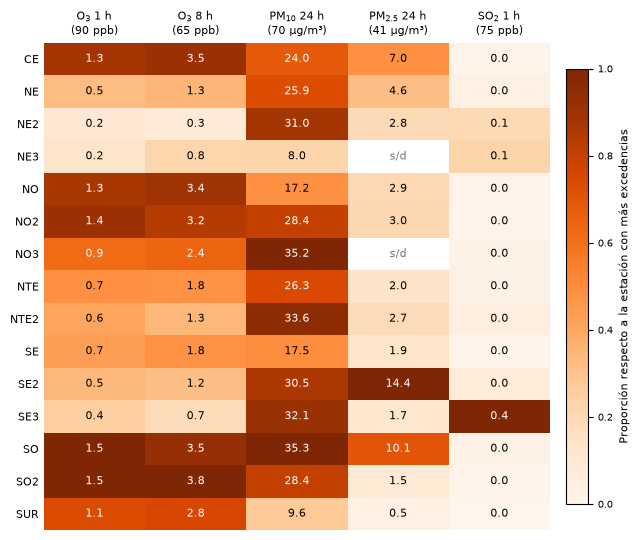

In [ ]:
COLUMNAS = ["O3 1h (90 ppb)", "PM10 24h (70 µg/m³)",
            "PM2.5 24h (41 µg/m³)", "SO2 1h (75 ppb)"]

pct = exc.pivot(index="Estacion", columns="Norma", values="%")[COLUMNAS]
periodos = exc.pivot(index="Estacion", columns="Norma", values="periodos")[COLUMNAS]

# Cobertura: periodos válidos / periodos posibles
dias_max = (datos["Fecha y hora"].max() - datos["Fecha y hora"].min()).days
cobertura = periodos.copy()
for c in COLUMNAS:
    cobertura[c] = periodos[c] / (dias_max if "24h" in c else dias_max * 24)
pocos = cobertura < 0.20                       # menos de 20 % de cobertura = sin datos suficientes

# Color relativo dentro de cada contaminante
relativo = (pct / pct.max()).mask(pocos)

fig, eje = plt.subplots(figsize=(6.5, 5.5))
im = eje.imshow(relativo.values, cmap="Oranges", vmin=0, vmax=1, aspect="auto")

for i in range(pct.shape[0]):
    for j in range(pct.shape[1]):
        if pocos.iloc[i, j]:
            eje.text(j, i, "s/d", ha="center", va="center", fontsize=8, color="#777777")
        else:
            eje.text(j, i, f"{pct.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8,
                     color="white" if relativo.iloc[i, j] > 0.6 else "black")

etiquetas = ["O$_3$ 1 h\n(90 ppb)", "PM$_{10}$ 24 h\n(70 µg/m³)",
             "PM$_{2.5}$ 24 h\n(41 µg/m³)", "SO$_2$ 1 h\n(75 ppb)"]
eje.set_xticks(range(len(COLUMNAS)), etiquetas, fontsize=8)
eje.set_yticks(range(len(pct.index)), pct.index, fontsize=8)
eje.xaxis.tick_top()
eje.tick_params(length=0)
for lado in eje.spines.values():
    lado.set_visible(False)

barra = fig.colorbar(im, ax=eje, fraction=0.04, pad=0.03)
barra.set_label("Proporción respecto a la estación con más excedencias", fontsize=8)
barra.ax.tick_params(labelsize=7)

fig.tight_layout()
fig.savefig(FIGURAS / "fig_excedencias_estacion.png", dpi=300, bbox_inches="tight")
plt.show()

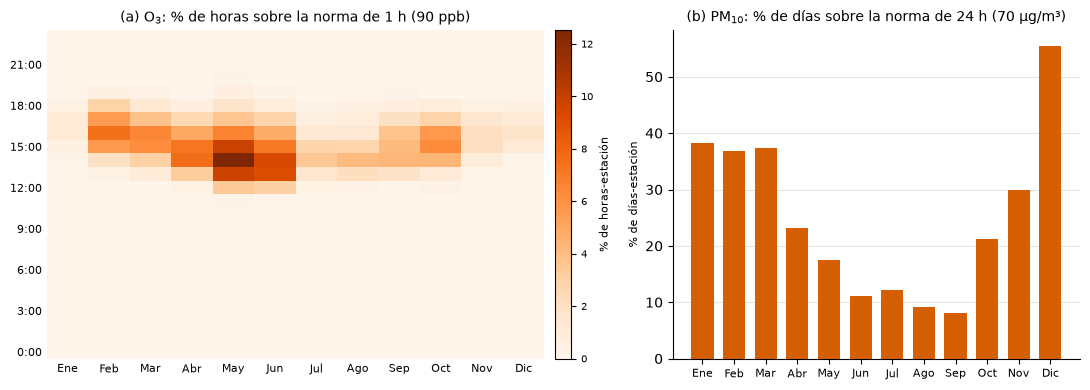

In [42]:
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

# (a) O3: % de horas sobre 90 ppb, por hora del día y mes
o3 = datos[["Fecha y hora", "O3"]].dropna()
o3["hora"] = o3["Fecha y hora"].dt.hour
o3["mes"] = o3["Fecha y hora"].dt.month
o3["excede"] = o3["O3"] > 90
tabla_o3 = o3.pivot_table(index="hora", columns="mes", values="excede", aggfunc="mean") * 100

# (b) PM10: % de días-estación con promedio de 24 h sobre 70 µg/m³, por mes
pm = (datos.set_index("Fecha y hora").groupby("Estacion")["PM10"]
           .resample("D").agg(["mean", "count"]).reset_index())
pm = pm[pm["count"] >= 18]                      # solo días con al menos 18 horas válidas
pm["mes"] = pm["Fecha y hora"].dt.month
pm["excede"] = pm["mean"] > 70
tabla_pm = pm.groupby("mes")["excede"].mean() * 100

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.3, 1]})

im = a.imshow(tabla_o3.values, cmap="Oranges", aspect="auto", origin="lower")
a.set_xticks(range(12), MESES, fontsize=8)
a.set_yticks(range(0, 24, 3), [f"{h}:00" for h in range(0, 24, 3)], fontsize=8)
a.set_title("(a) O$_3$: % de horas sobre la norma de 1 h (90 ppb)", fontsize=10)
a.tick_params(length=0)
for lado in a.spines.values():
    lado.set_visible(False)
barra = fig.colorbar(im, ax=a, fraction=0.04, pad=0.02)
barra.set_label("% de horas-estación", fontsize=8)
barra.ax.tick_params(labelsize=7)

b.bar(range(1, 13), tabla_pm.reindex(range(1, 13)).values, color="#D55E00", width=0.7)
b.set_xticks(range(1, 13), MESES, fontsize=8)
b.set_ylabel("% de días-estación", fontsize=8)
b.set_title("(b) PM$_{10}$: % de días sobre la norma de 24 h (70 µg/m³)", fontsize=10)
b.grid(axis="y", color="#E5E5E5", linewidth=0.8)
b.set_axisbelow(True)
for lado in ["top", "right"]:
    b.spines[lado].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURAS / "fig_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

Ozono: Las horas en las que se concentran las excedencias son entre las 12:00 y las 18:00, con el pico entre las 14:00 y las 15:00. En la noche y en la madrugada practicamente no hay excedencias. Los meses en que esto ocurrió fueorn de febrero a junio con el máximo en mayor (alrededor de 12% de las horas a las 14:00). Hay un segundo pico más pequeño en septiembre y octubre. los meses más bajos son noviembre a enero y julio y agosto. Esto tiene sentido a nivel químico ya que el ozono no se emite directamente, se forma cuando la radiación solar descomono el NO2. Por eso al no haber sol, no hay excedencias de noche, se acumula durante el día (el tráfico emite los precursores y el ozono se va fromando conforme sube la radiación por eso el pico a media tarde). Otro factor es que los meses con calor y poca humedad osea marzo-mayo hay mayor que en invierno. Entre julio y agosto puede ser que la humedad o la lluvia reduzcan la radiación aunque esto es una hipótesis. 

En cuanto a Pm10, la temporada crítica es de noviembre a marzo, con un máximo en diciembre (55%); esto corresponde a más de la mitad de los días -estación que rebasan la norma. La única temporada baja es de junio a septiembre. Esto puede ser debido a que en inverno el aire se enfría con la altura y el aire caliente sube, lo que se lleva los contamiantes o puede ser que estos queden atrapados cerca del suelo. La lluvia y el aire en verano pueden hacer las partículas sean arrastradas al suelo y por eso estos meses con lluvia presentan menos excesos. También hay que considerar que en diciembre o festividades los fuegos artificales aumentan y por eso hay un pico el 31 de diciembre en año nuevo. 

Ambos contaminantes mencionados anteriormente tienen temporadas distintias . Hay que tomarlo en cuenta para el modelo, la hora del día y el mes ya que estos pueden entrar como covariables y con efectos distintos para cada contaminante. Para el ozono, la probabilidad de excedencia de noche es prácticamente cero y el modelo lo tiene que reflejar. Otra cosa importante que se debe de considerar es que 2025 termina en junio y 2026 en julio, por lo que las segunda mitad del asño se calcula con menos información.


       Buena  Aceptable   Mala  Muy mala  Extremadamente mala
O3     93.29       5.84   0.84      0.03                 0.00
NO2    99.02       0.95   0.03      0.00                 0.00
SO2    99.71       0.24   0.04      0.00                 0.00
CO     99.76       0.24   0.00      0.00                 0.00
PM10   37.28      37.31  23.26      2.07                 0.08
PM2.5  35.68      60.01   4.16      0.15                 0.01


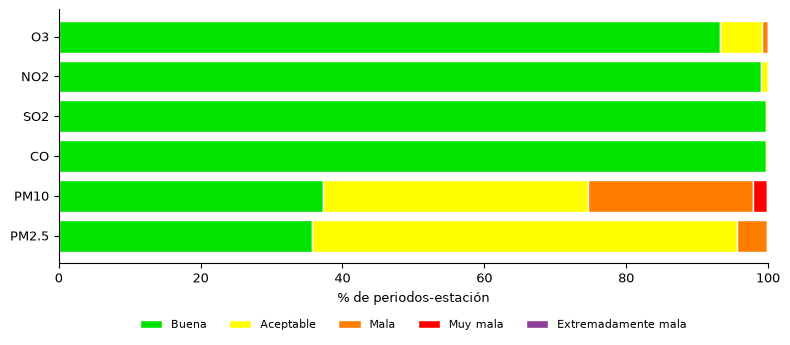

In [43]:
# Índice AIRE Y SALUD (NOM-172-SEMARNAT-2023): límites superiores de
# Buena, Aceptable, Mala y Muy mala. PM con los valores iniciales (fijos para comparar años).
BANDAS = {
    #  contaminante: (promedio, [límites], unidad)
    "O3":    ("1h",       [58, 90, 135, 175],  "ppb"),
    "NO2":   ("1h",       [53, 106, 160, 213], "ppb"),
    "SO2":   ("1h",       [35, 75, 185, 304],  "ppb"),
    "CO":    ("8h móvil", [5, 9, 12, 16],      "ppm"),
    "PM10":  ("24h",      [45, 70, 132, 213],  "µg/m³"),
    "PM2.5": ("24h",      [15, 41, 79, 130],   "µg/m³"),
}
CATEGORIAS = ["Buena", "Aceptable", "Mala", "Muy mala", "Extremadamente mala"]

filas = []
for c, (prom, limites, uni) in BANDAS.items():
    valores = pd.concat([serie_promediada(df_est, c, prom).dropna()
                         for _, df_est in datos.groupby("Estacion")])
    cat = pd.cut(valores, bins=[-np.inf] + limites + [np.inf], labels=CATEGORIAS)
    filas.append((100 * cat.value_counts(normalize=True)).reindex(CATEGORIAS).rename(c))

indice = pd.DataFrame(filas)
print(indice.round(2))

COLORES_NOM = ["#00E400", "#FFFF00", "#FF7E00", "#FF0000", "#8F3F97"]   # Tabla 11 de la NOM-172

fig, eje = plt.subplots(figsize=(8, 3.6))
izquierda = np.zeros(len(indice))
for cat, color in zip(CATEGORIAS, COLORES_NOM):
    eje.barh(indice.index, indice[cat], left=izquierda, color=color,
             edgecolor="white", linewidth=1, label=cat)
    izquierda += indice[cat].fillna(0).values
eje.invert_yaxis()
eje.set_xlim(0, 100)
eje.set_xlabel("% de periodos-estación", fontsize=9)
eje.tick_params(labelsize=9)
for lado in ["top", "right"]:
    eje.spines[lado].set_visible(False)
eje.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
fig.tight_layout()
fig.savefig(FIGURAS / "fig_indice.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
# O3: solo de 12:00 a 18:00, para comparar a la misma hora del día
o3 = datos[datos["Fecha y hora"].dt.hour.between(12, 18)].dropna(subset=["O3"]).copy()
o3["grupo"] = np.where(o3["O3"] > 90, "Excede", "No excede")

# PM10: promedios diarios por estación (la lluvia se suma en el día)
d = datos.set_index("Fecha y hora").groupby("Estacion")
pm = d[["PM10", "TOUT", "RH", "WSR"]].resample("D").mean()
pm["RAINF"] = d["RAINF"].resample("D").sum(min_count=18)
pm["horas"] = d["PM10"].resample("D").count()
pm = pm[pm["horas"] >= 18].reset_index()
pm["grupo"] = np.where(pm["PM10"] > 70, "Excede", "No excede")

print("O3, medianas (12 a 18 h):")
print(o3.groupby("grupo")[["SR", "TOUT", "RH", "WSR"]].median().round(2))
print("\nPM10, medianas diarias:")
print(pm.groupby("grupo")[["TOUT", "RH", "WSR"]].median().round(2))
print("\n% de días con lluvia:")
print((pm.groupby("grupo")["RAINF"].apply(lambda x: (x.dropna() > 0).mean()) * 100).round(1))

O3, medianas (12 a 18 h):
             SR   TOUT    RH   WSR
grupo                             
Excede     0.53  33.22  32.0  11.5
No excede  0.34  28.48  42.0  10.6

PM10, medianas diarias:
            TOUT     RH   WSR
grupo                        
Excede     22.70  51.17  7.23
No excede  25.07  59.92  8.29

% de días con lluvia:
grupo
Excede        2.3
No excede    11.1
Name: RAINF, dtype: float64


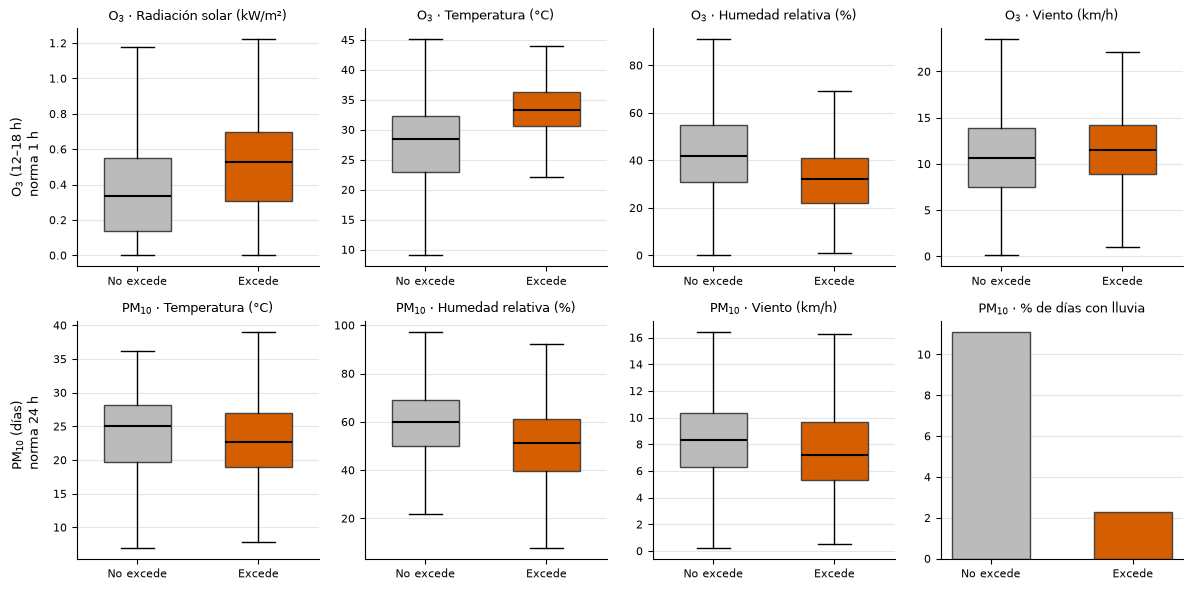

In [45]:
PANELES = [
    (o3, "SR",    "O$_3$ · Radiación solar (kW/m²)"),
    (o3, "TOUT",  "O$_3$ · Temperatura (°C)"),
    (o3, "RH",    "O$_3$ · Humedad relativa (%)"),
    (o3, "WSR",   "O$_3$ · Viento (km/h)"),
    (pm, "TOUT",  "PM$_{10}$ · Temperatura (°C)"),
    (pm, "RH",    "PM$_{10}$ · Humedad relativa (%)"),
    (pm, "WSR",   "PM$_{10}$ · Viento (km/h)"),
    (pm, "RAINF", "PM$_{10}$ · % de días con lluvia"),
]
COLORES = {"No excede": "#BBBBBB", "Excede": "#D55E00"}
grupos = ["No excede", "Excede"]

fig, ejes = plt.subplots(2, 4, figsize=(12, 6))
for eje, (df, var, titulo) in zip(ejes.flat, PANELES):
    if var == "RAINF":
        # Casi todos los días tienen 0 mm: una caja no mostraría nada,
        # así que se compara el % de días con lluvia
        valores = [100 * (df.loc[df["grupo"] == g, var].dropna() > 0).mean() for g in grupos]
        eje.bar(grupos, valores, color=[COLORES[g] for g in grupos], edgecolor="#444444", width=0.55)
    else:
        valores = [df.loc[df["grupo"] == g, var].dropna() for g in grupos]
        cajas = eje.boxplot(valores, tick_labels=grupos, showfliers=False, patch_artist=True,
                            widths=0.55, medianprops=dict(color="black", linewidth=1.5))
        for caja, g in zip(cajas["boxes"], grupos):
            caja.set_facecolor(COLORES[g])
            caja.set_edgecolor("#444444")
    eje.set_title(titulo, fontsize=9)
    eje.tick_params(labelsize=8)
    eje.grid(axis="y", color="#E5E5E5", linewidth=0.8)
    eje.set_axisbelow(True)
    for lado in ["top", "right"]:
        eje.spines[lado].set_visible(False)

fig.text(0.01, 0.73, "O$_3$ (12–18 h)\nnorma 1 h", fontsize=9, rotation=90, va="center")
fig.text(0.01, 0.27, "PM$_{10}$ (días)\nnorma 24 h", fontsize=9, rotation=90, va="center")
fig.tight_layout(rect=[0.03, 0, 1, 1])
fig.savefig(FIGURAS / "fig_meteorologia.png", dpi=300, bbox_inches="tight")
plt.show()

El ozono si aumenta cuando hay más radiación, más calor y menos humedad. Esto se puede observar una vez que se analizan las gráficas y se hace la comparación de las tardes a la misma hora. Sin embargo, hay que considerar que el viento puede hacer que se exceda un poco, lo cual es algo inesperado ya que uno pensaría que el vieno dispersa la contaminación. Algo que lo podría explicar es que cuando hay viento, este viaje con él o trae ozono que se forma en otra parte hacia la estación. Maybe y es una pregunta interesante para el reporte (más ozno en las estaciones del oeste? siguen un patrón geográfico?)

En cuanto al PM10, al comparar los días si se excede cuando hay menos viento y menos lluvia y con los días más fríos. Hay que considerar que también los días secos hacen que el polvo del suelo se levante (según una búsqueda en google es resuspensión)

En cuanta a las gráficas de cajas, se traslapan en casi todas las variables. La temperatura del ozono es la que mejor serpara los grupos, la caja "Excede" (31-36ºC) esta casi toda por encima de la mediana de "No excede!. Para la radiación y humedad del ozono, la separación es moderada aunque las cajas se traslapan bastante. Y en cuando al viento, en los dos contamintenes y tempratura del PM 10, se traslapan casi por completo. Casi no se distinguen los grupos. 

Lo que sí importa es que ninguna variable por sí sola distingue bien los días con excedencia de los días sin ella. Osea por ejemplo un día frío y sin viento y sin lluvia puede ser diferente de uno que solo cumple una característica de los tres. 

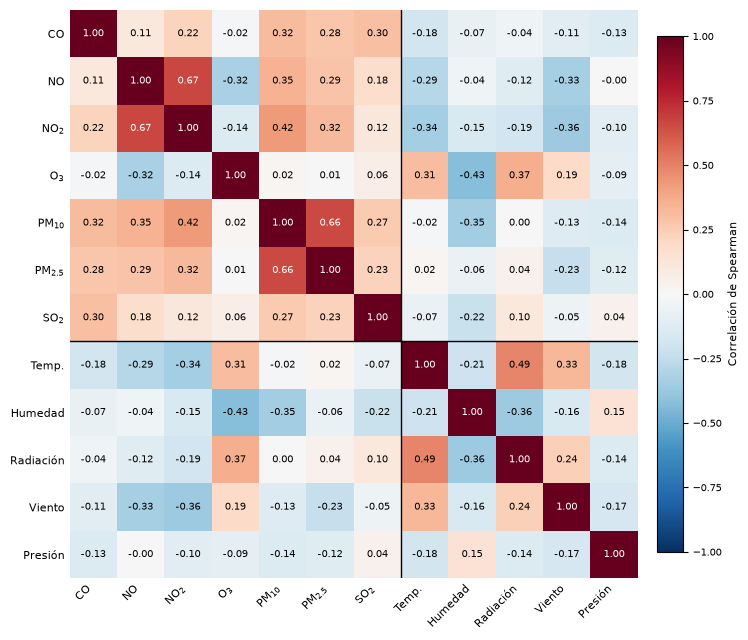

In [46]:
VARIABLES = ["CO", "NO", "NO2", "O3", "PM10", "PM2.5", "SO2",
             "TOUT", "RH", "SR", "WSR", "PRS"]
NOMBRES = ["CO", "NO", "NO$_2$", "O$_3$", "PM$_{10}$", "PM$_{2.5}$", "SO$_2$",
           "Temp.", "Humedad", "Radiación", "Viento", "Presión"]

# Promedios diarios por estación: todas las variables en la misma escala de tiempo
diario_corr = (datos.set_index("Fecha y hora").groupby("Estacion")[VARIABLES]
                    .resample("D").mean())
corr = diario_corr.corr(method="spearman")

fig, eje = plt.subplots(figsize=(7.5, 6.5))
im = eje.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
for i in range(len(VARIABLES)):
    for j in range(len(VARIABLES)):
        r = corr.iloc[i, j]
        eje.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if abs(r) > 0.6 else "black")
eje.set_xticks(range(len(VARIABLES)), NOMBRES, rotation=45, ha="right", fontsize=8)
eje.set_yticks(range(len(VARIABLES)), NOMBRES, fontsize=8)
eje.axhline(6.5, color="black", linewidth=1)      # separa contaminantes de meteorología
eje.axvline(6.5, color="black", linewidth=1)
eje.tick_params(length=0)
for lado in eje.spines.values():
    lado.set_visible(False)
barra = fig.colorbar(im, ax=eje, fraction=0.04, pad=0.03)
barra.set_label("Correlación de Spearman", fontsize=8)
barra.ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(FIGURAS / "fig_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()

O3 y No tienen correlación negativa de (-0.32). Esto según el documento de nuestro amigo querido Gyarmati, el NO consume ozono, y esto lo hace cuando hay mucho NO, como cerca del tráfico hay menos ozono. Por eso el =3 es el único contaminante que no pertenece al bloque de los primarios y tiene una correlación casi cero con PM10 y PM2.5 y negativa con NO y NO2. 

O3 tiene correlación de -0,43 con humedad, 0.37 con radiación, 0.31 con temperatura y 0.19 con vienteo. Esto pues ya es algo claro de que si aumenta cuando hay masa sol, más calor y menso humedad. 

PM10: -0.35 con humedad es la más fuerte, el viento es débil -0.13 y la temperatura es prácticamente cero -0.02. Esto es interesante porque anteriormente habíamos visto que lagunos días con escedencia de PM10 eran 2.4ºC osea temperaturas frías, pero pues aquí no se relaciona. Esto sucede porque la temperatura parece importar en la cola pero no en el promedio. Osea tiene relación con los valores extremos y una relación diferente con valores típicos. (esto nos daun argumento)


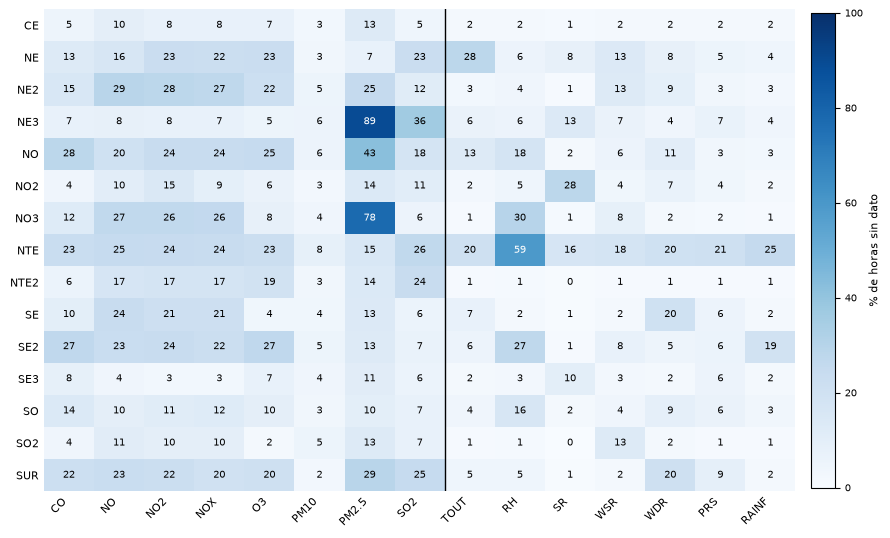

In [47]:
VARS_FALT = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "SO2",
             "TOUT", "RH", "SR", "WSR", "WDR", "PRS", "RAINF"]
faltantes = datos.groupby("Estacion")[VARS_FALT].apply(lambda d: d.isna().mean() * 100)

fig, eje = plt.subplots(figsize=(9, 5.5))
im = eje.imshow(faltantes.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
for i in range(faltantes.shape[0]):
    for j in range(faltantes.shape[1]):
        v = faltantes.iloc[i, j]
        eje.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                 color="white" if v > 55 else "black")
eje.set_xticks(range(len(VARS_FALT)), VARS_FALT, fontsize=8, rotation=45, ha="right")
eje.set_yticks(range(len(faltantes.index)), faltantes.index, fontsize=8)
eje.axvline(7.5, color="black", linewidth=1)      # separa contaminantes de meteorología
eje.tick_params(length=0)
for lado in eje.spines.values():
    lado.set_visible(False)
barra = fig.colorbar(im, ax=eje, fraction=0.03, pad=0.02)
barra.set_label("% de horas sin dato", fontsize=8)
barra.ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(FIGURAS / "fig_faltantes.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
datos.groupby([datos["Estacion"], datos["Fecha y hora"].dt.year]).size().unstack()

Fecha y hora,2020,2021,2022,2023,2024,2025,2026
Estacion,,,,,,,
CE,8784.0,8760.0,8760.0,8758.0,8784.0,4344.0,5087.0
NE,8776.0,8759.0,8760.0,8758.0,8784.0,4343.0,5087.0
NE2,8776.0,8759.0,8760.0,8758.0,8782.0,4342.0,5087.0
NE3,NaN,8759.0,8760.0,8757.0,8782.0,4320.0,5087.0
NO,8778.0,8759.0,8760.0,8758.0,8783.0,4343.0,5087.0
NO2,8776.0,8759.0,8760.0,8759.0,8782.0,4343.0,5086.0
NO3,NaN,NaN,743.0,8759.0,8784.0,4320.0,5085.0
NTE,8777.0,8759.0,8760.0,8758.0,8782.0,4344.0,5086.0
NTE2,8776.0,8759.0,8760.0,8758.0,8782.0,4343.0,5087.0


NE3 no tiene datos en el 2020, por loq ue lo más probable es que hubiera empezado a a operar en el 2021. NO3 empezó en diciembre de 2022. Por lo tanto, durante el COVID solo había 13 de 15 estaciones hayq ue tomarlo en cuenta para hacer bien la comparación. 

Las variables que tienen más valores faltantes es PM2.5 89% en NE3, 78% en NO3 y 43% en NO. En cuanto NO, NO2 y NOX con 15 a 29%, también estos tienen procentajes casi iguales en cada estación por lo que se miden con el mismo y cuando este falla pues fallan todos. PM10 es la más complete y también el contaminante con más excedencias (YEIII ) 

Las fallas por sensores pueden ser en Pm2.5, NE3 , RH, NTE, SR, NO2, TOUT en NE. Y falla por toda la estación: NTE entre 15 y 25% en todas las variables (cortes de luz, mantenimiento, etc..)

Por lo tanto, hay combinaciones que no se pueden modelar PM2.5 en NE3 y NO3 ya que no tienen datos suficientes. 

Una pregunta es que los faltantes ocuuren al azar?  Por que CO falló justo después de un pico y la calibración del NO esta rodeado de huecos. Si es que los sensores fallam ás seguido durante los episodios de contaminación alta, entonces los faltantes no son aleatorios pero pues puede ser una pregunta verdad??  no digo que hay que responderla ahorita solo es una pregunta...OJOOOO

In [ ]:
#entre días
CONTAM = ["CO", "NO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
tipo = np.where(datos["Fecha y hora"].dt.dayofweek >= 5, "Fin de semana", "Entre semana")
tabla_dia = datos.groupby(tipo)[CONTAM].median().T
tabla_dia["Cambio fin de semana (%)"] = 100 * (tabla_dia["Fin de semana"] / tabla_dia["Entre semana"] - 1)
tabla_dia.round(1)

,Entre semana,Fin de semana,Cambio fin de semana (%)
CO,1.2,1.2,-1.7
NO,5.2,4.5,-13.5
NO2,11.8,9.9,-16.1
O3,23.0,25.0,8.7
PM10,50.0,45.0,-10.0
PM2.5,17.0,16.3,-4.0
SO2,3.9,3.9,0.0
